In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


DATA CLEANING AND PREPROCESSING

Dataset Shape: (5110, 12)

Columns:
 Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

Missing Values:
 id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

First 5 Rows:
       id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

    

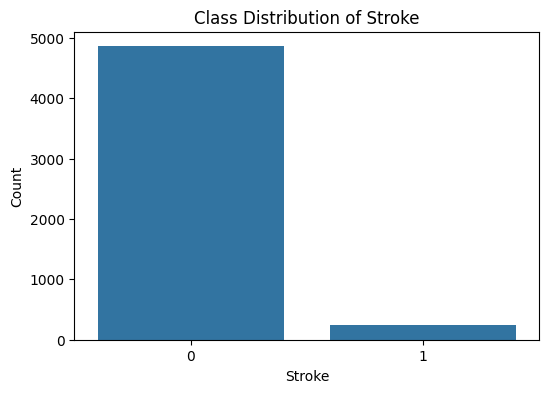

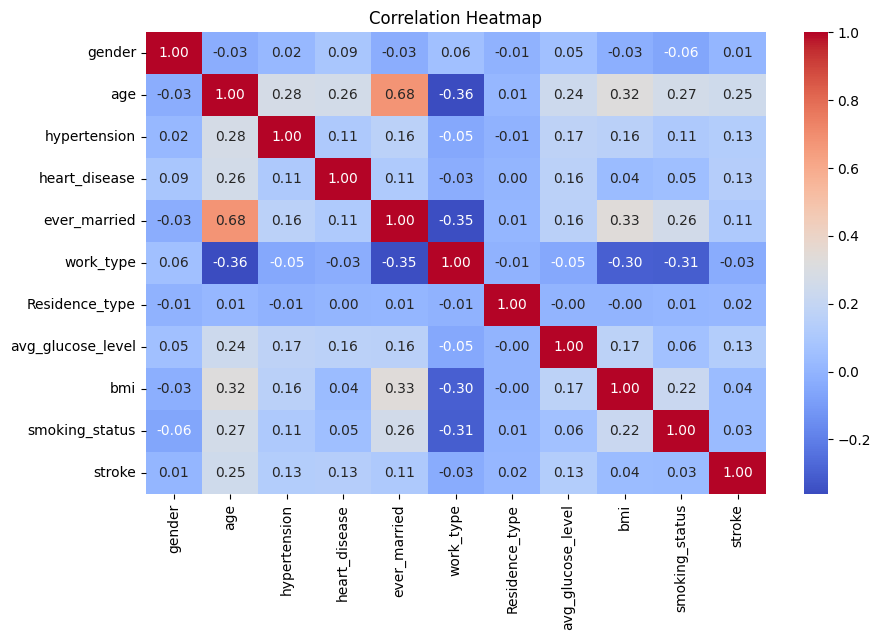


Data preprocessing completed successfully.


In [2]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# 2. Load dataset
df = pd.read_csv('/content/drive/MyDrive/Master Project/Dataset/healthcare-dataset-stroke-data.csv')

# 3. Display basic information
print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing Values:\n", df.isnull().sum())
print("\nFirst 5 Rows:\n", df.head())

# 4. Drop unnecessary column
df = df.drop(columns=['id'])

# 5. Remove rare gender category if present
if 'Other' in df['gender'].unique():
    df = df[df['gender'] != 'Other']

# 6. Handle missing values in BMI using median
imputer = SimpleImputer(strategy='median')
df['bmi'] = imputer.fit_transform(df[['bmi']])

# 7. Encode categorical variables
categorical_cols = df.select_dtypes(include=['object']).columns

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# 8. Final missing values check
print("\nMissing Values After Cleaning:\n", df.isnull().sum())

# 9. Class distribution
print("\nStroke Class Distribution:\n", df['stroke'].value_counts())

# 10. Plot class distribution
plt.figure(figsize=(6,4))
sns.countplot(x='stroke', data=df)
plt.title("Class Distribution of Stroke")
plt.xlabel("Stroke")
plt.ylabel("Count")
plt.show()

# 11. Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

# 12. Split features and target
X = df.drop('stroke', axis=1)
y = df['stroke']

# 13. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 14. Scale data for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 15. Save feature names for SHAP
feature_names = X.columns.tolist()

print("\nData preprocessing completed successfully.")

MODEL DEVELOPMENT AND EVALUATION

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:37:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Logistic Regression
--------------------------------------------------
Accuracy : 0.7358
Precision: 0.1333
Recall   : 0.8
F1-score : 0.2286
ROC-AUC  : 0.8363

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.73      0.84       972
           1       0.13      0.80      0.23        50

    accuracy                           0.74      1022
   macro avg       0.56      0.77      0.53      1022
weighted avg       0.94      0.74      0.81      1022

Confusion Matrix:
 [[712 260]
 [ 10  40]]

Random Forest
--------------------------------------------------
Accuracy : 0.9501
Precision: 0.0
Recall   : 0.0
F1-score : 0.0
ROC-AUC  : 0.7782

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
wei

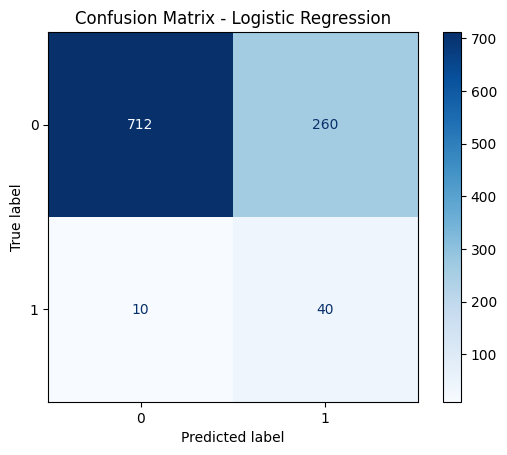

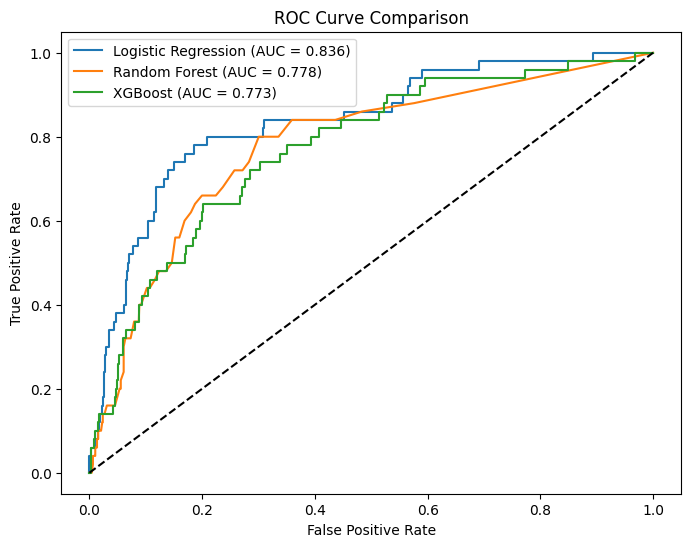

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:38:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:38:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:38:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:38:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Cross-Validation Results:
                 Model  Mean ROC-AUC   Std Dev
0  Logistic Regression      0.836346  0.019859
1        Random Forest      0.811750  0.012255
2              XGBoost      0.793253  0.013288


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:38:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)

from sklearn.model_selection import StratifiedKFold, cross_val_score

# 1. Define models
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

# Handle imbalance for XGBoost
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

# 2. Train models
lr.fit(X_train_scaled, y_train)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

# 3. Evaluation function
def evaluate_model(name, model, X_test_data, y_test_data):
    y_pred = model.predict(X_test_data)
    y_prob = model.predict_proba(X_test_data)[:, 1]

    acc = accuracy_score(y_test_data, y_pred)
    prec = precision_score(y_test_data, y_pred, zero_division=0)
    rec = recall_score(y_test_data, y_pred, zero_division=0)
    f1 = f1_score(y_test_data, y_pred, zero_division=0)
    auc = roc_auc_score(y_test_data, y_prob)

    print(f"\n{name}")
    print("-" * 50)
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1-score :", round(f1, 4))
    print("ROC-AUC  :", round(auc, 4))
    print("\nClassification Report:\n", classification_report(y_test_data, y_pred, zero_division=0))
    print("Confusion Matrix:\n", confusion_matrix(y_test_data, y_pred))

    return {
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "ROC-AUC": auc
    }, y_pred, y_prob

# 4. Evaluate models
results = []

lr_result, lr_pred, lr_prob = evaluate_model("Logistic Regression", lr, X_test_scaled, y_test)
rf_result, rf_pred, rf_prob = evaluate_model("Random Forest", rf, X_test, y_test)
xgb_result, xgb_pred, xgb_prob = evaluate_model("XGBoost", xgb, X_test, y_test)

results.extend([lr_result, rf_result, xgb_result])

# 5. Results table
results_df = pd.DataFrame(results)
print("\nFinal Results Table:")
print(results_df)

# 6. Confusion Matrix for best model (Logistic Regression)
cm = confusion_matrix(y_test, lr_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# 7. ROC Curve comparison
plt.figure(figsize=(8,6))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, lr_prob):.3f})")

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_score(y_test, rf_prob):.3f})")

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {roc_auc_score(y_test, xgb_prob):.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# 8. Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_scaled = scaler.fit_transform(X)

lr_cv = cross_val_score(lr, X_scaled, y, cv=cv, scoring='roc_auc')
rf_cv = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc')
xgb_cv = cross_val_score(xgb, X, y, cv=cv, scoring='roc_auc')

cv_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Mean ROC-AUC": [lr_cv.mean(), rf_cv.mean(), xgb_cv.mean()],
    "Std Dev": [lr_cv.std(), rf_cv.std(), xgb_cv.std()]
})

print("\nCross-Validation Results:")
print(cv_results)

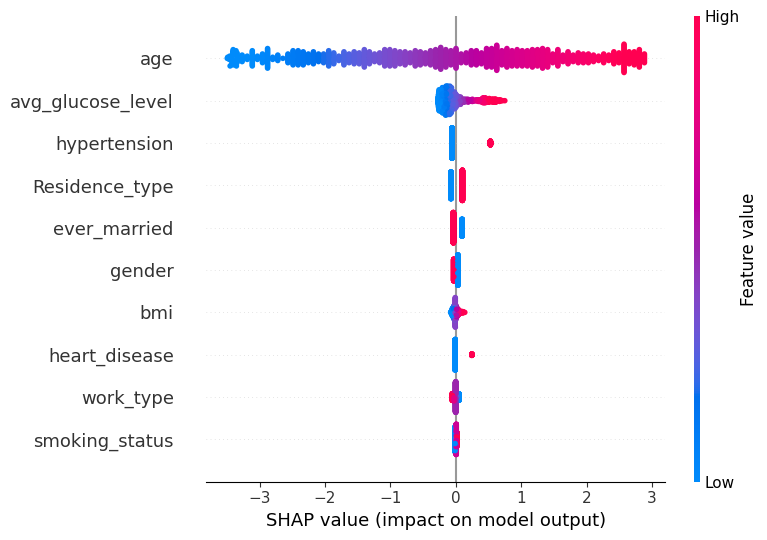

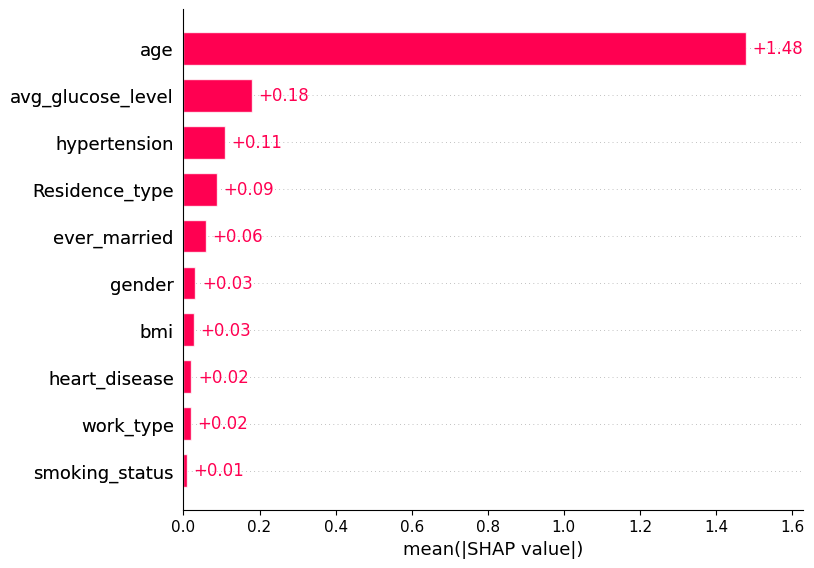

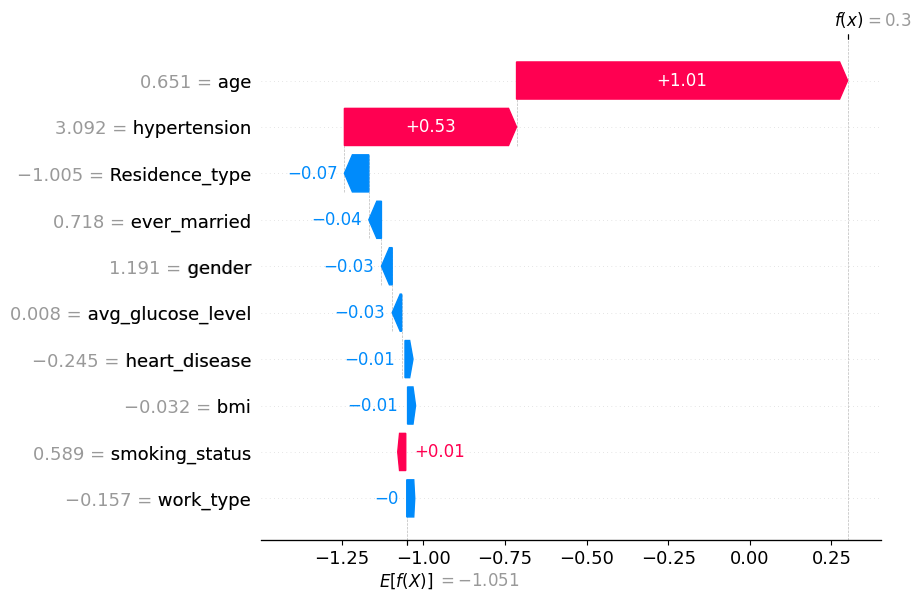

All files saved successfully.


In [ ]:
# ==========================================
# PART 3: SHAP EXPLAINABILITY
# ==========================================

!pip install shap -q

import shap
shap.initjs()

# 1. Convert scaled arrays to DataFrames for feature names
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_names)

# 2. Create SHAP explainer for Logistic Regression
explainer = shap.Explainer(lr, X_train_scaled_df)

# 3. Generate SHAP values
shap_values = explainer(X_test_scaled_df)

# 4. SHAP Summary Plot
shap.summary_plot(shap_values, X_test_scaled_df)

# 5. SHAP Bar Plot
shap.plots.bar(shap_values)

# 6. SHAP Waterfall Plot for first instance
shap.plots.waterfall(shap_values[150])

shap.plots.force(shap_values[150])

from IPython.display import display
display(shap.plots.force(shap_values[150]))

shap.save_html("force_plot.html", shap.plots.force(shap_values[150]))

# Save trained Logistic Regression model
with open("model.pkl", "wb") as f:
    pickle.dump(lr, f)

# Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save label encoders
with open("label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)

# Save feature names
with open("feature_names.pkl", "wb") as f:
    pickle.dump(feature_names, f)

with open("X_train_scaled_df.pkl", "wb") as f:
    pickle.dump(X_train_scaled_df.sample(200, random_state=42), f)

print("All files saved successfully.")